In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from typing import Union
from sklearn.linear_model import LinearRegression
import joblib

In [76]:
df = pd.read_csv('atp_singles.csv')

In [77]:
df['rank_diff'] = df['loser_rank'] - df['winner_rank']
df['age_diff']  = df['winner_age'] - df['loser_age']
target = 'minutes'

In [78]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
exclude = [target]
candidates = [col for col in numeric_cols if col not in exclude]

temp_df = df[candidates + [target]].dropna()

corr = temp_df.corr()[target].abs().sort_values(ascending=False)

best_features = corr.index[1:16].tolist()   
print("Selected Features:")
print(best_features)

Selected Features:
['w_svpt', 'l_svpt', 'l_SvGms', 'w_SvGms', 'w_1stIn', 'l_1stIn', 'l_1stWon', 'w_1stWon', 'l_2ndWon', 'w_2ndWon', 'w_bpFaced', 'best_of', 'w_bpSaved', 'l_bpFaced', 'l_bpSaved']


In [79]:
model = Ridge(alpha=10.0)
model.fit(X_train_s, y_train)

y_val_pred  = model.predict(X_val_s)
y_test_pred = model.predict(X_test_s)

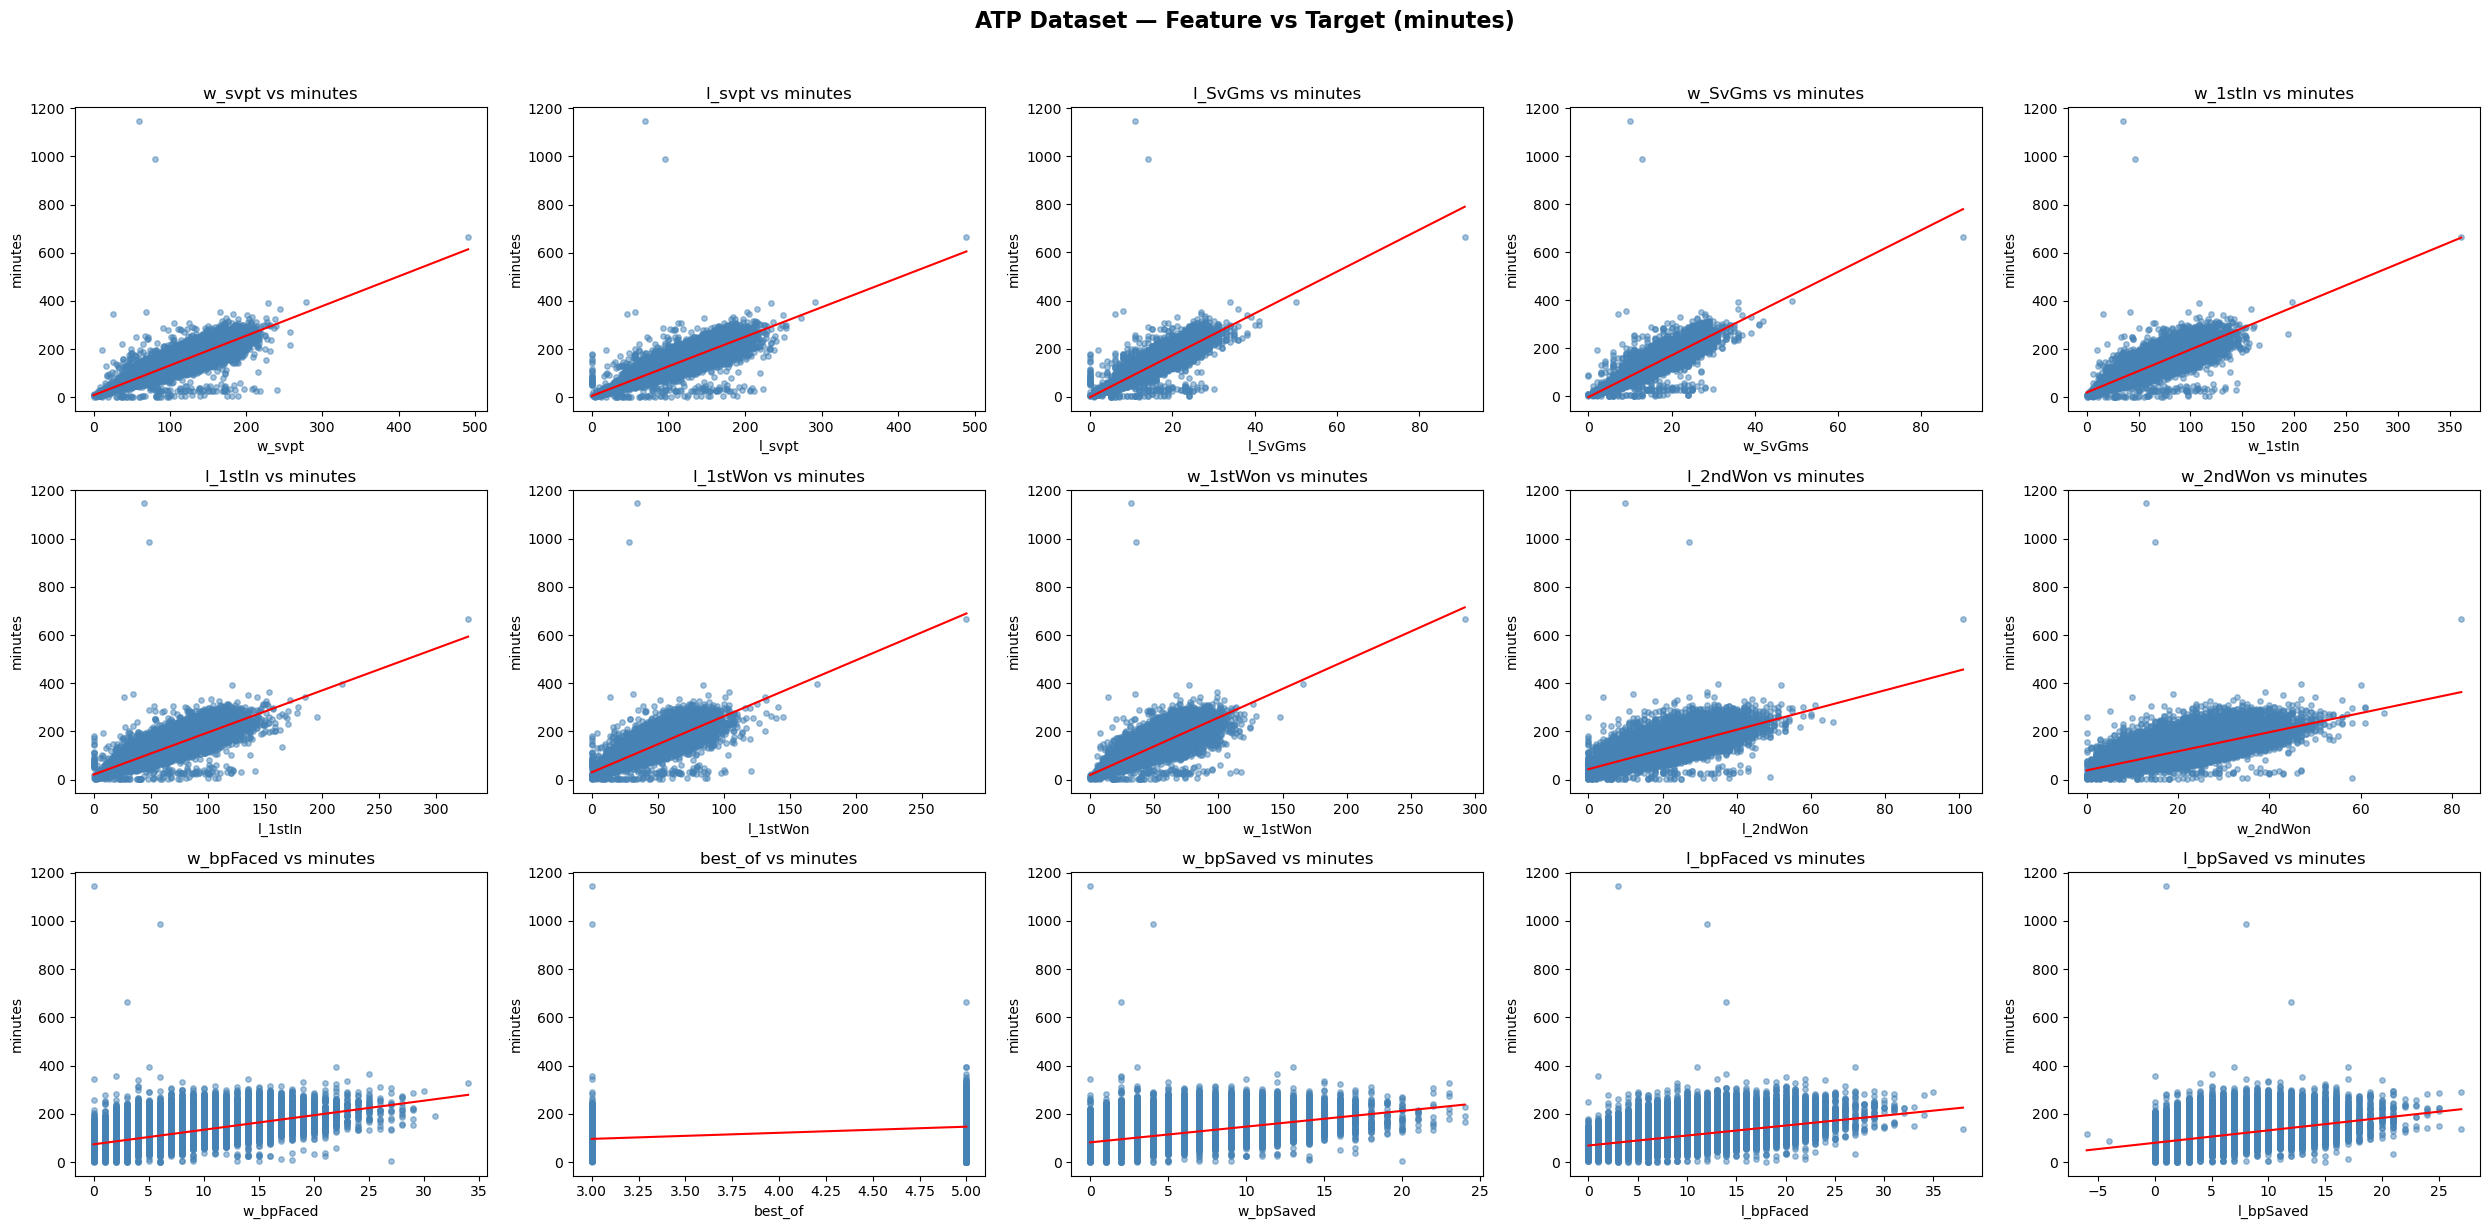

In [80]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 5, figsize=(25, 12))  
axes = axes.flatten()

for i, feat in enumerate(best_features):
    axes[i].scatter(df_final[feat], df_final[target], alpha=0.5, s=15, color='steelblue')
    
    # Fit a linear line
    m, b = np.polyfit(df_final[feat], df_final[target], 1)
    x_line = np.linspace(df_final[feat].min(), df_final[feat].max(), 100)
    axes[i].plot(x_line, m*x_line + b, 'r-', lw=1.5)
    
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(target)
    axes[i].set_title(f'{feat} vs {target}')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('ATP Dataset — Feature vs Target (minutes)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [81]:
df_final = df[best_features + [target]].dropna()

X = df_final[best_features].values
y = df_final[target].values 
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15/0.85,
    random_state=42)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Train : (66516, 15)
Val   : (14254, 15)
Test  : (14254, 15)


In [82]:

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

def ols_fit(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])
    w_star = np.linalg.pinv(X_b.T @ X_b) @ (X_b.T @ y)
    return w_star

def ols_predict(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])
    return X_b @ w


w_ols = ols_fit(X_train_s, y_train)

print('OLS Weights (intercept + feature coefficients):')
print(f'  Intercept : {w_ols[0]:.4f}')
for name, coef in zip(best_features, w_ols[1:]):
    print(f'  {name:>6} : {coef:.4f}')

y_val_pred  = ols_predict(X_val_s, w_ols)
y_test_pred = ols_predict(X_test_s, w_ols)




OLS Weights (intercept + feature coefficients):
  Intercept : 104.2858
  w_svpt : 15.5713
  l_svpt : 13.7225
  l_SvGms : 4.8836
  w_SvGms : 8.4542
  w_1stIn : 9.1913
  l_1stIn : 6.4616
  l_1stWon : -7.1253
  w_1stWon : -12.3419
  l_2ndWon : 0.4605
  w_2ndWon : -1.2949
  w_bpFaced : 0.0053
  best_of : -1.6167
  w_bpSaved : 0.7623
  l_bpFaced : -5.3963
  l_bpSaved : 4.8955


In [83]:
def evaluate(y_true, y_pred, label):

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    print(f"{label} Performance:")
    print(f"  MSE:  {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²:   {r2:.4f}")

    return mse, rmse, r2
    evaluate(y_val,  y_val_pred,  "Validation")
evaluate(y_test, y_test_pred, "Test")

Test Performance:
  MSE:  209.35
  RMSE: 14.47
  R²:   0.8648


(209.3512836762212, np.float64(14.468976593948211), 0.8648464449648662)

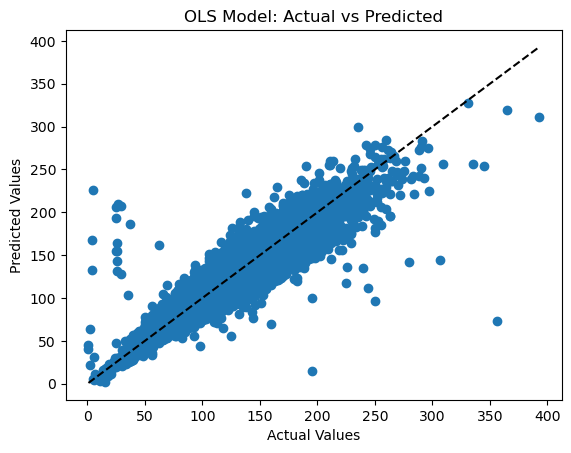

In [84]:
from sklearn.linear_model import LinearRegression

model_ols = LinearRegression()
model_ols.fit(X_train, y_train)

y_test_ols = model_ols.predict(X_test)

mask = ~(np.isnan(y_test) | np.isinf(y_test) | np.isnan(y_test_ols) | np.isinf(y_test_ols))
y_test_clean = y_test[mask]
y_test_ols_clean = y_test_ols[mask]

plt.scatter(y_test_clean, y_test_ols_clean)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('OLS Model: Actual vs Predicted')
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'k--')
plt.show()

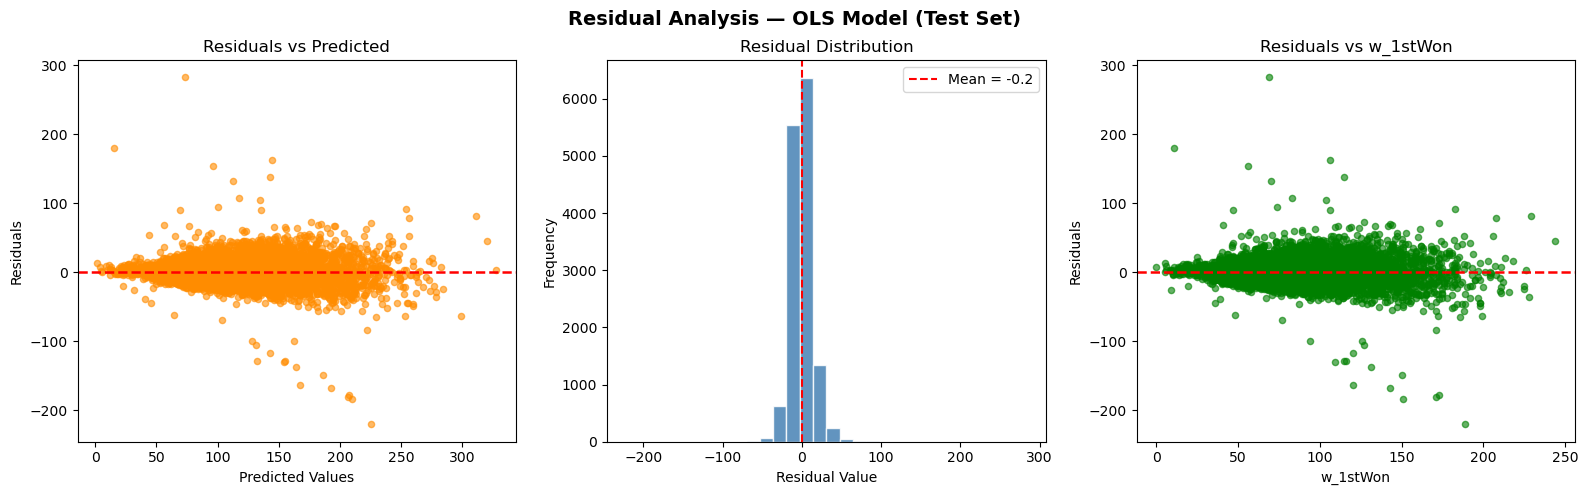

Residual stats — mean: -0.245, std: 14.467
Min: -220.6, Max: 282.3
Model performance — RMSE: 14.469, R²: 0.865


In [85]:
from sklearn.metrics import mean_squared_error, r2_score

residuals = y_test - y_test_ols

mask = ~(np.isnan(y_test) | np.isinf(y_test) | np.isnan(y_test_ols) | np.isinf(y_test_ols))
y_test_clean = y_test[mask]
y_test_ols_clean = y_test_ols[mask]
residuals_clean = residuals[mask]
X_test_clean = X_test[mask]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))


axes[0].scatter(y_test_ols_clean, residuals_clean, alpha=0.6, s=20, color='darkorange')
axes[0].axhline(0, color='red', lw=1.8, ls='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')


axes[1].hist(residuals_clean, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(residuals_clean.mean(), color='red', ls='--', lw=1.5, 
                label=f'Mean = {residuals_clean.mean():.1f}')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()


axes[2].scatter(X_test_clean[:, bmi_idx], residuals_clean, alpha=0.6, s=20, color='green')
axes[2].axhline(0, color='red', lw=1.8, ls='--')
axes[2].set_xlabel(feature_name)
axes[2].set_ylabel('Residuals')
axes[2].set_title(f'Residuals vs {feature_name}')

plt.suptitle('Residual Analysis — OLS Model (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88)  
plt.show()


print(f'Residual stats — mean: {residuals_clean.mean():.3f}, std: {residuals_clean.std():.3f}')
print(f'Min: {residuals_clean.min():.1f}, Max: {residuals_clean.max():.1f}')


rmse = np.sqrt(mean_squared_error(y_test_clean, y_test_ols_clean))
r2 = r2_score(y_test_clean, y_test_ols_clean)
print(f'Model performance — RMSE: {rmse:.3f}, R²: {r2:.3f}')

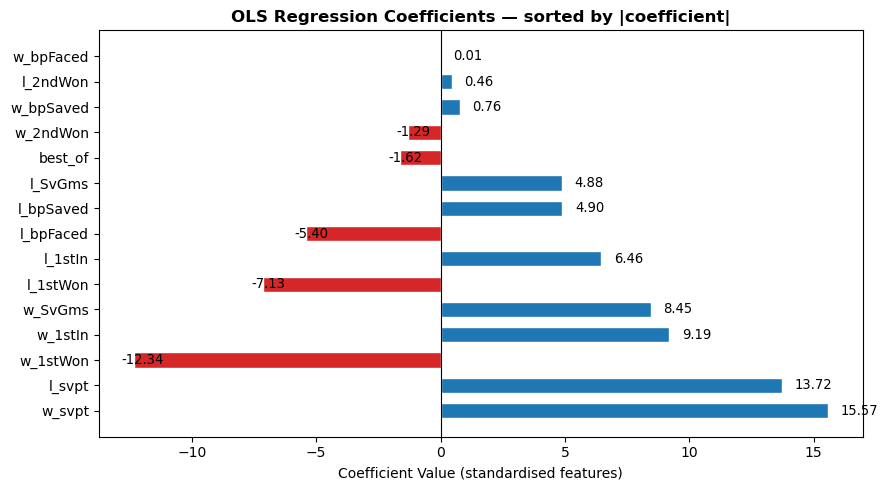

In [86]:
import matplotlib.pyplot as plt
import numpy as np

coef_vals = w_ols[1:]

sorted_idx = np.argsort(np.abs(coef_vals))[::-1]
sorted_feats = [features[i] for i in sorted_idx]
sorted_coefs = coef_vals[sorted_idx]
colors = ['#d62728' if c < 0 else '#1f77b4' for c in sorted_coefs]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sorted_feats, sorted_coefs, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient Value (standardised features)')
ax.set_title('OLS Regression Coefficients — sorted by |coefficient|', fontweight='bold')
for bar, val in zip(bars, sorted_coefs):
    offset = 0.5 if val >= 0 else -0.5
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9.5)
plt.tight_layout()
plt.show()

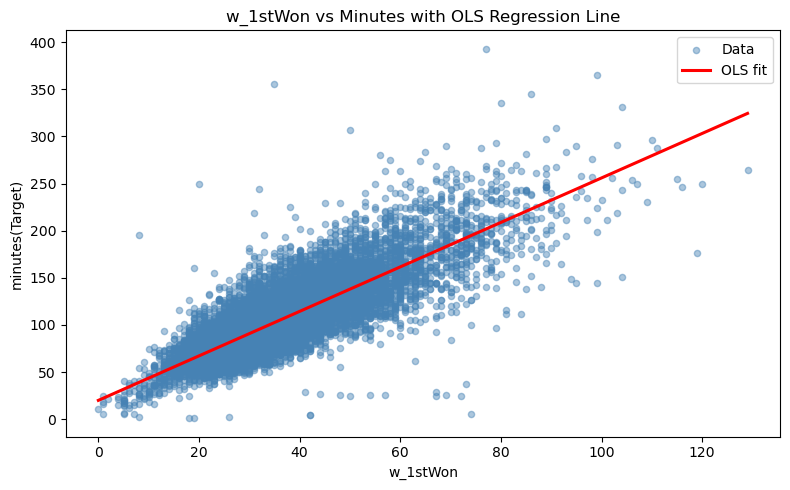

In [87]:
import matplotlib.pyplot as plt
import numpy as np

feature_name = 'w_1stWon'
feature_idx = features.index(feature_name)


feature_values = X_test[:, feature_idx] 
target_values = y_test 

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(feature_values, target_values, alpha=0.45, s=20, 
           color='steelblue', label='Data')

x_line = np.linspace(feature_values.min(), feature_values.max(), 200)
m, b = np.polyfit(feature_values, target_values, 1)
ax.plot(x_line, m*x_line + b, 'r-', lw=2.2, label='OLS fit')

ax.set_xlabel(f'{feature_name}')
ax.set_ylabel('minutes' '(Target)')
ax.set_title(f'{feature_name} vs Minutes with OLS Regression Line')
ax.legend()

plt.tight_layout()
plt.show()

In [88]:
print('COEFFICIENT INTERPRETATION (on standardised features)')
print('='*60)
print(f'Intercept: {w_ols[0]:.2f} → baseline prediction (mean of match duration)')
print()

for name, coef in zip(features, w_ols[1:]):
    direction = 'INCREASES' if coef > 0 else 'DECREASES'
    print(f'{name:>10}: {coef:>8.2f}  → 1 SD increase in {name} {direction} '
          f'match duration by {abs(coef):.2f} minutes')


COEFFICIENT INTERPRETATION (on standardised features)
Intercept: 104.29 → baseline prediction (mean of match duration)

    w_svpt:    15.57  → 1 SD increase in w_svpt INCREASES match duration by 15.57 minutes
    l_svpt:    13.72  → 1 SD increase in l_svpt INCREASES match duration by 13.72 minutes
   l_SvGms:     4.88  → 1 SD increase in l_SvGms INCREASES match duration by 4.88 minutes
   w_SvGms:     8.45  → 1 SD increase in w_SvGms INCREASES match duration by 8.45 minutes
   w_1stIn:     9.19  → 1 SD increase in w_1stIn INCREASES match duration by 9.19 minutes
   l_1stIn:     6.46  → 1 SD increase in l_1stIn INCREASES match duration by 6.46 minutes
  l_1stWon:    -7.13  → 1 SD increase in l_1stWon DECREASES match duration by 7.13 minutes
  w_1stWon:   -12.34  → 1 SD increase in w_1stWon DECREASES match duration by 12.34 minutes
  l_2ndWon:     0.46  → 1 SD increase in l_2ndWon INCREASES match duration by 0.46 minutes
  w_2ndWon:    -1.29  → 1 SD increase in w_2ndWon DECREASES match 

In [96]:
import joblib

joblib.dump({
    'weights': w_ols,
    'feature_names': features
}, 'tennis_model.joblib')

print('Model saved successfully to "tennis_model.joblib"')

Model saved successfully to "tennis_model.joblib"
